In [1]:
# Import the required libraries for the programme.
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# This is the sample diabetes dataset which we will be using for testing on Batch Gradient Descent .
# First we will use Simple linear Regression which uses OLS and we will compare that to our BGDRegressor using coef_,intercept_ and r2score.
X , y = load_diabetes(return_X_y=True) # Returns X and y for the dataset.

In [3]:
X.shape,y.shape # Analyze the shape of the dataset

((442, 10), (442,))

In [4]:
# Split into training and testing set 
X_train , X_test , y_train ,y_test = train_test_split(X ,y ,test_size=0.2,random_state=2)

In [5]:
lr = LinearRegression() # Instantiate the model

In [6]:
lr.fit(X_train,y_train) # Fit parameters

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
print( f"coef : {lr.coef_} \n intercept : {lr.intercept_}" ) # Examine the coef and intercept which will be used for further comparision.

coef : [  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238] 
 intercept : 151.88331005254167


In [8]:
y_pred_lr = lr.predict(X_test) # Store the predictions 

In [9]:
r2_score(y_test,y_pred_lr) # Always make sure y_test comes first .

0.439933866156897

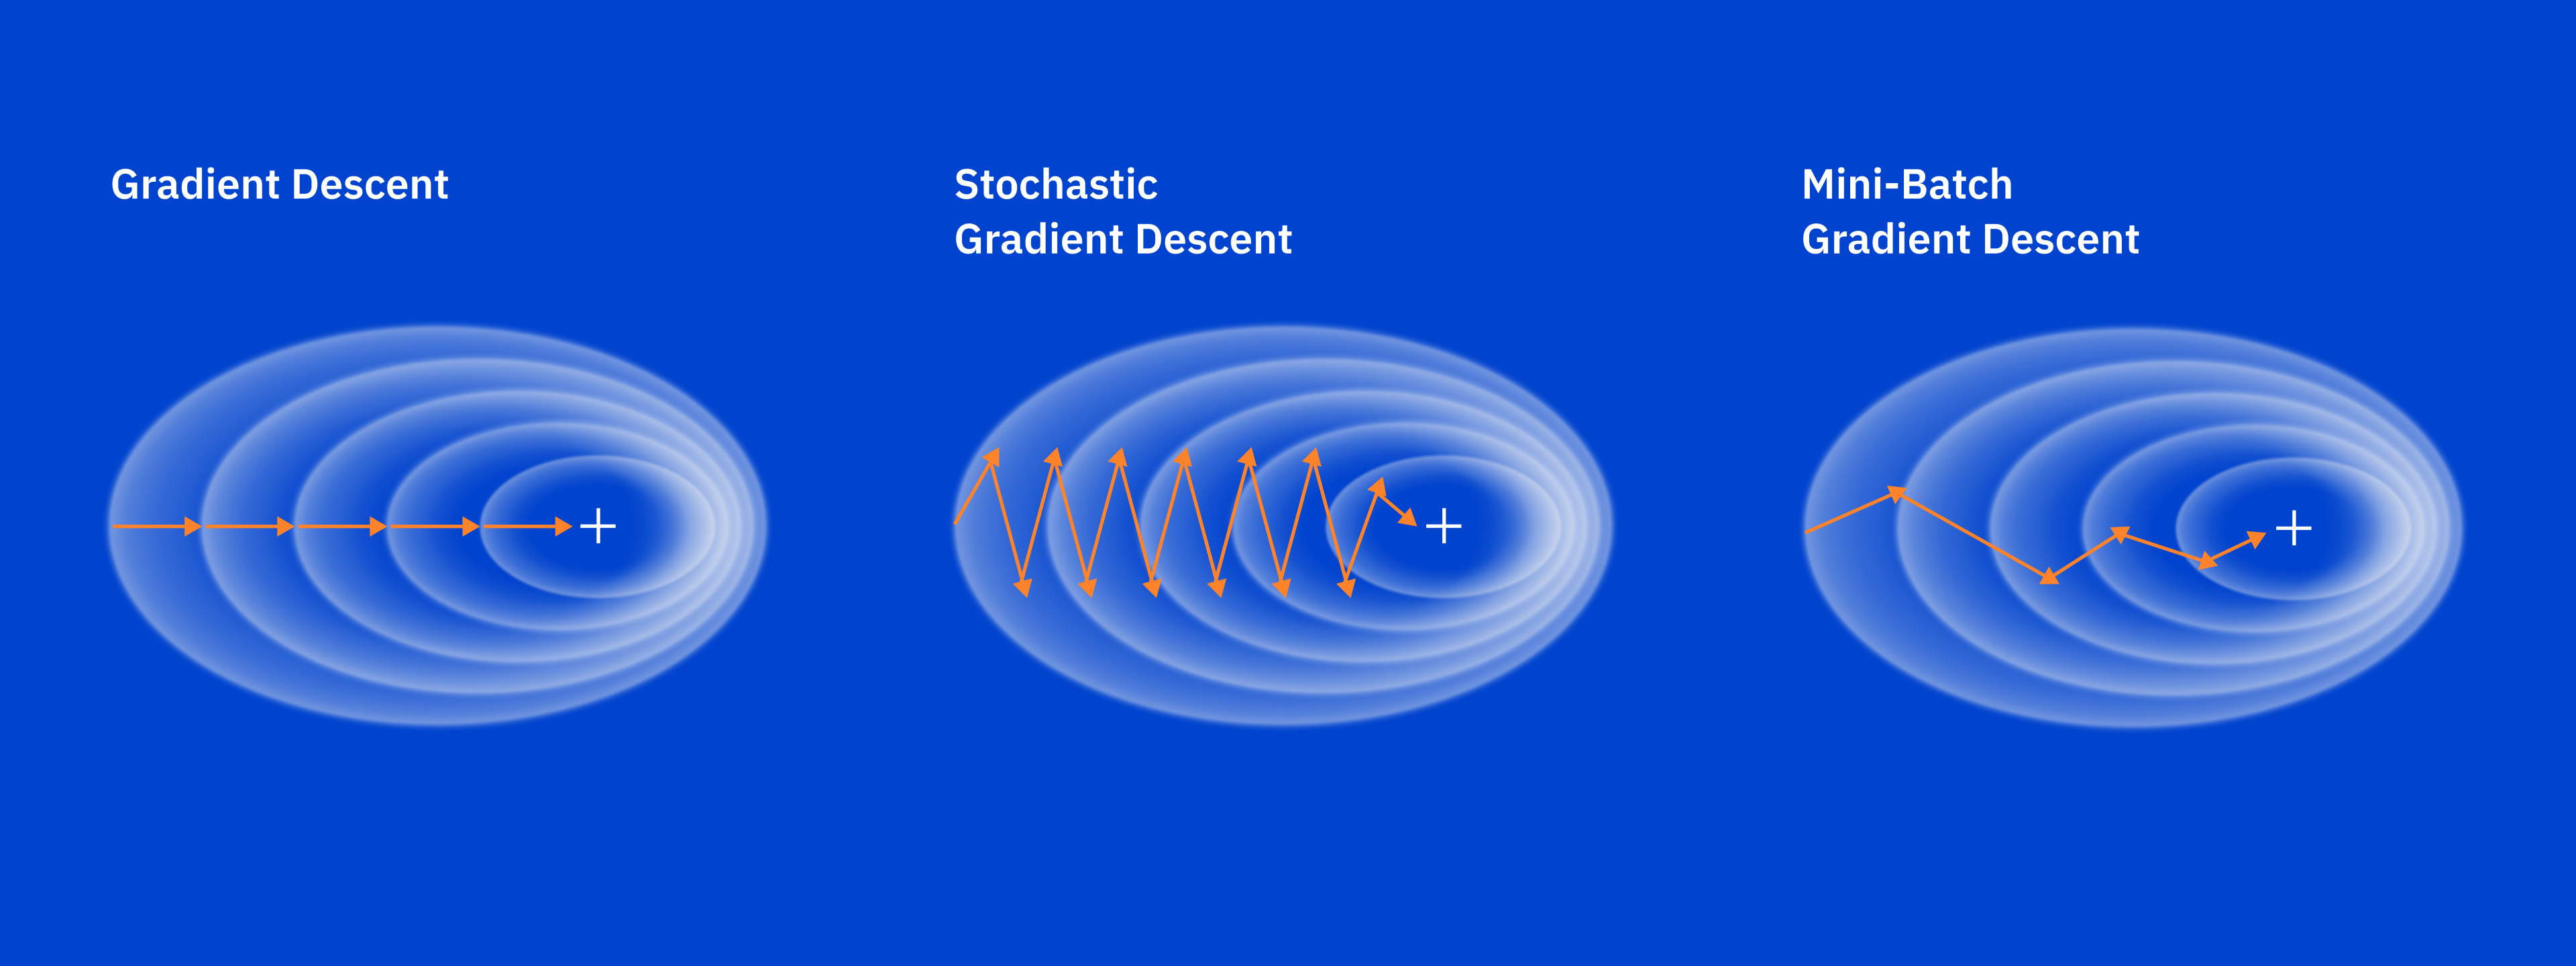

In [10]:
# Stochastic Gradient Descent from scratch
class SGDRegressor:
    def __init__(self,learning_rate = 0.01 , epochs = 100 ):
        self.coef = None
        self.intercept = None
        self.l = learning_rate
        self.epochs = epochs

    def fit(self,X_train,y_train):

        # Now we have to initialize the values first here so that we have the base values for calculating coef and intercept.
        # Note : When we did the Gradient Descent algorithm this steps were not done as the values were passed 
        # and then recalculated step by step. This is also due to vecotrized approach used here unlike GDR (scalar approach).
        # Also remember that shape return two value : row[0],column[1]
        self.intercept = 0
        self.coef = np.ones(X_train.shape[1]) # Make sure we are making empty columns here 

        # Now looping till epochs limit 
        for i in range(self.epochs):
            for j in range(X_train.shape[0]): # Make sure we are looping over no of rows (samples)
                idx = np.random.randint(0,X_train.shape[0]) # We will take a random number between intervals (0,row_size)
                # In previous BGRegression we used to calculate the total yhat matrix at once using summation.
                # but here we will calculate the value for each one by one in each iteraion , returning a scalar value at each iteration.
                y_hat = self.intercept + np.dot(X_train[idx],self.coef) # we will pass the index of random idx

                # Also for calcualtion of the intercept_deri we will be using the single value and not the summation,
                # also no division by no of rows.
                intercept_deri = -2 * (y_train[idx] - y_hat)
                # Calculating new intercept value 
                self.intercept = self.intercept - (self.l * intercept_deri)

                # Also changes in coef_deri
                # We dont need to use the summation anywmore and we will do computations for each value.
                coef_deri = -2 * (np.dot((y_train[idx] - y_hat),X_train[idx]))

                # Now we can use this to calculate coef
                self.coef = self.coef - (self.l * coef_deri)


        print( f"coef : {self.coef} \n intercept : {self.intercept}" )
    
    def predict(self,X_test):
        return (np.dot(X_test,self.coef) + self.intercept)

# Stochastic Gradient Descent (SGD): Complete Explanation

## Complete Example Walkthrough

### Dataset Setup

```python
X_train = [[10, 2],    # House 1: 1000 sqft, 2 bedrooms
           [15, 3],    # House 2: 1500 sqft, 3 bedrooms
           [20, 4]]    # House 3: 2000 sqft, 4 bedrooms

y_train = [250, 350, 450]  # Prices in $1000s
```

### Initial Parameters

```python
self.intercept = 0
self.coef = [1, 1]
self.l = 0.01
```

**Initial model:** ŷ = 0 + 1×size + 1×bedrooms

---

### Epoch 1, Update 1

**Step 1: Random selection**
```python
idx = np.random.randint(0, 3)  # Say we get idx = 1
```

**Step 2: Forward pass**
```python
X_train[idx] = [15, 3]
y_train[idx] = 350

y_hat = 0 + np.dot([15, 3], [1, 1])
      = 0 + (15 + 3)
      = 18
```

**Step 3: Compute residual**
```python
residual = y_train[idx] - y_hat
         = 350 - 18
         = 332
```

**Step 4: Compute gradients**
```python
intercept_deri = -2 × 332 = -664

coef_deri = -2 × (332 × [15, 3])
          = -2 × [4980, 996]
          = [-9960, -1992]
```

**Step 5: Update parameters**
```python
self.intercept = 0 - (0.01 × (-664))
               = 0 + 6.64
               = 6.64

self.coef = [1, 1] - (0.01 × [-9960, -1992])
          = [1, 1] + [99.6, 19.92]
          = [100.6, 20.92]
```

**New parameters:** β₀ = 6.64, β₁ = 100.6, β₂ = 20.92

**New model:** ŷ = 6.64 + 100.6×size + 20.92×bedrooms

---

### Epoch 1, Update 2

**Step 1: Random selection**
```python
idx = np.random.randint(0, 3)  # Say we get idx = 0
```

**Step 2: Forward pass**
```python
X_train[idx] = [10, 2]
y_train[idx] = 250

y_hat = 6.64 + np.dot([10, 2], [100.6, 20.92])
      = 6.64 + (1006 + 41.84)
      = 1054.48
```

**Step 3: Compute residual**
```python
residual = 250 - 1054.48
         = -804.48  # We're now OVERpredicting!
```

**Step 4: Compute gradients**
```python
intercept_deri = -2 × (-804.48) = 1608.96

coef_deri = -2 × (-804.48 × [10, 2])
          = -2 × [-8044.8, -1608.96]
          = [16089.6, 3217.92]
```

**Step 5: Update parameters**
```python
self.intercept = 6.64 - (0.01 × 1608.96)
               = 6.64 - 16.09
               = -9.45

self.coef = [100.6, 20.92] - (0.01 × [16089.6, 3217.92])
          = [100.6, 20.92] - [160.90, 32.18]
          = [-60.3, -11.26]
```

**New parameters:** β₀ = -9.45, β₁ = -60.3, β₂ = -11.26

---

### What Just Happened?

**Update 1:**
- Started at: [0, 1, 1]
- Saw sample with large error (underpredicting by 332)
- Jumped parameters way up: [6.64, 100.6, 20.92]

**Update 2:**
- Now at: [6.64, 100.6, 20.92]
- Saw different sample (now overpredicting by 804)
- Swung parameters way down: [-9.45, -60.3, -11.26]

**This zigzagging is characteristic of SGD!**

The path looks like:
```
        Update 1
          ↗
Start ●
          ↘
        Update 2
```

Over many iterations, these oscillations average out.

---

### Epoch 1, Update 3

**Step 1: Random selection**
```python
idx = np.random.randint(0, 3)  # Say we get idx = 2
```

**Step 2: Forward pass**
```python
X_train[idx] = [20, 4]
y_train[idx] = 450

y_hat = -9.45 + np.dot([20, 4], [-60.3, -11.26])
      = -9.45 + (-1206 + (-45.04))
      = -9.45 + (-1251.04)
      = -1260.49
```

**Step 3: Compute residual**
```python
residual = 450 - (-1260.49)
         = 1710.49  # Massively underpredicting!
```

**And the dance continues...**

Over 100 epochs × 3 samples = 300 updates, the parameters will gradually converge despite the noise.

---

## Comparison: Batch GD vs SGD

### Convergence Paths Visualization

**Batch GD:**
```
Iteration  |  β₀   |  β₁   |  β₂   | Loss
-----------|-------|-------|-------|------
    0      |  0.0  |  1.0  |  1.0  | 116114
    1      |  6.6  | 106.9 | 22.2  |  ???
    2      |  ...  |  ...  |  ...  |  ???
   ...     |  ...  |  ...  |  ...  |  ↓
   50      | 45.2  | 18.3  |  8.1  |  125
```
Path: Smooth descent

**SGD:**
```
Update  |  β₀   |  β₁   |  β₂   | Sample Loss
--------|-------|-------|-------|-------------
   1    |  6.6  | 100.6 | 20.9  |  High
   2    | -9.5  | -60.3 |-11.3  |  High
   3    |  ...  |  ...  |  ...  |  ???
  ...   |  ↕    |  ↕    |  ↕    |  ↕
  300   | ~45   | ~18   | ~8    |  ~Low
```
Path: Noisy, oscillating

---





In [11]:
# There are some misconceptions where we are not able to use all the possible combinations as any value 
# in randint can be repeated and some values may be skipped .
# We need a more robust method for this .

# Also to improve the performance we can use learning schedule to update l each iteration using a learning function ,
# because the steps taken by the algorithm to reach the goal becomes slow epoch by epoch

In [12]:
model = SGDRegressor(epochs=50,learning_rate=0.02) 
# Note that the no of epochs are less so even though the model looks for n sample in each iteration (epoch) ,
# we reach convergence fast because there are less no of epochs needed as we are looking for n samples each epoch.
# This is the actual intution for the Stochastic Gradient Descent algorithm.

In [13]:
model.fit(X_train,y_train) # fit the model with parameters.
# The coefecients and the intercept are somewhat different from the actual ones.

coef : [  23.87341362 -140.38919018  455.31836297  299.9987967   -25.86621122
  -95.78588242 -199.10254286  112.46063048  413.14844447  114.96997189] 
 intercept : 138.16955687638767


In [14]:
y_pred = model.predict(X_test) # make predictions and store it in a variable

In [15]:
r2_score(y_test,y_pred) # calculate the r2 score 
# The r2 score was found to be greater than the model.

0.41782111417267553

In [ ]:
# Below code will be a improvement on the code above 
class StochasticGradientDescent:

    def __init__(self,learning_rate = 0.1,epochs = 50 , t0 = 50 , t1 = 100):
        # Added t0 and t1 for setting the decay parameters.
        self.l = learning_rate
        self.epochs = epochs
        self.intercepts = None
        self.coeffecients = None
        self.t0 = t0
        self.t1 = t1

    def learning_rate_(self,t):
        # Dynamic or Static Learning rate set depending on the user's choice.
        if self.t0 is not None and self.t1 is not None:
            return (self.t0/(self.t1 + t)) # Returns true only if user has set t0 and t1
        return self.l

    def fit(self,X_train,y_train):

        self.intercepts = 0 
        self.coeffecients = np.zeros(X_train.shape[1]) # Start Neural instead

        t = 0 # Global parameter initialization

        for i in range(self.epochs):

            indices = np.random.permutation(X_train.shape[0])

            for idx in indices :
                
                y_hat = np.dot(X_train[idx],self.coeffecients) + self.intercepts

                error = y_hat - y_train[idx] # We will use this symbol generated here instead of using the negative sign in the derivation

                intercept_gradient = 2 * error
                coeffecient_gradient = 2 * (error*X_train[idx]) # As error was scalar we dont need dot product for it .

                current_lr = self.learning_rate_(t) # Update the current learning rate.

                t+=1 

                self.intercepts -= current_lr * intercept_gradient
                self.coeffecients -= current_lr * coeffecient_gradient
                
            
    def predict(self,X_test):
        return np.dot(X_test,self.coeffecients) + self.intercepts
    


In [ ]:
# Improvements and the idealogy :
'''
Firstly I added a learning schedule that automatically updates the learning rate automactically after each iteration,
so that the solution is converged faster as if the learning rate is kept stable and high the solution will be reached slower
with a lot of iterations .
        So we used a decay function : t0 / t + t1
Here basic idealogy is that we have to reduce the value of our learning rate as time passes.
So we use a global parameter t initialized with 0 to be passed and then we update it according to the looping done in each epoch incrementally.

Second thing I found out was we were basically using the negative sign of the derivation for switching the direction of the slopes
but instead we could have just used y_hat - y[idx] instead because we can use the direction from this equation as it is.
Suppose if the actual value is 7(y[idx]) and predicted value is 8(y_hat) then we get 8-7 = 1 (we are 1 units far).
This is handled automaticaly when we calculate the new values for intercepts and coeffecients as positive values automatically 
brings down weight.

Lastly we changes the matrix initialization from ones to zeros as ones i a huge assumption from the start and many impact the accuracy 
and the time taken to reach the solution because of this assumption.
Also we changed the error dot product with X_train[idx] to vector multplication because to begin with we were using
a scalar (error) and vector(X_train[idx])
'''

In [ ]:
std1 = StochasticGradientDescent(learning_rate=0.2) # Experimenting must be done for more accuratte results

In [ ]:
std1.fit(X_train,y_train) # Fit the parameters

In [ ]:
y_pred_std = std1.predict(X_test) # Predict the values

In [ ]:
r2_score(y_test,y_pred_std) # Compute the r2 score 

0.44211852185103373